# Exploratory Data Analysis (EDA) & Data Cleaning Assessment

## Hotel Booking Cancellation Analysis


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

df = pd.read_csv("hotel_bookings.csv")  #load dataset

df.head()



,hotel,lead_time,stays_in_weekend_nights,stays_in_week_nights,adults,children,country,market_segment,adr,is_canceled
0,Resort Hotel,45,2,5,2,0,IND,Online TA,5200,0
1,City Hotel,120,1,3,2,1,USA,Online TA,6800,1
2,Resort Hotel,15,1,2,2,0,IND,Direct,4500,0
3,City Hotel,200,2,4,2,0,UK,Corporate,7200,1
4,City Hotel,90,1,2,1,0,CAN,Online TA,6000,0


## 1.Data Inspection

In [2]:
print("Dataset Shape:", df.shape)  #shape

df.info()

df.describe().T  #statisical summary

df.isnull().sum() #missing values



Dataset Shape: (20, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   hotel                    20 non-null     object
 1   lead_time                20 non-null     int64 
 2   stays_in_weekend_nights  20 non-null     int64 
 3   stays_in_week_nights     20 non-null     int64 
 4   adults                   20 non-null     int64 
 5   children                 20 non-null     int64 
 6   country                  20 non-null     object
 7   market_segment           20 non-null     object
 8   adr                      20 non-null     int64 
 9   is_canceled              20 non-null     int64 
dtypes: int64(7), object(3)
memory usage: 1.7+ KB


hotel                      0
lead_time                  0
stays_in_weekend_nights    0
stays_in_week_nights       0
adults                     0
children                   0
country                    0
market_segment             0
adr                        0
is_canceled                0
dtype: int64

### Missing values are observed in columns such as country, agent, company, and children.
These columns require cleaning before analysis.

## 2.Data cleaning

In [4]:
duplicates = df.duplicated().sum()  #checking duplicates
print("Duplicates:", duplicates)

df = df.drop_duplicates()  #removing duplicates
print("Remaining Duplicates:", df.duplicated().sum())

df["country"] = df["country"].fillna(
    df["country"].mode()[0]
)  #filling missing values in country column with mode

df["children"] = df["children"].fillna(
    df["children"].median()
)  #filling missing values in children column with median

df.isnull().sum() #verifying nulls

Duplicates: 0
Remaining Duplicates: 0


hotel                      0
lead_time                  0
stays_in_weekend_nights    0
stays_in_week_nights       0
adults                     0
children                   0
country                    0
market_segment             0
adr                        0
is_canceled                0
dtype: int64

## 3.Visual Analysis

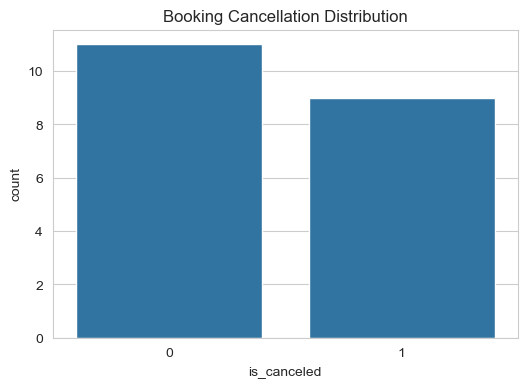

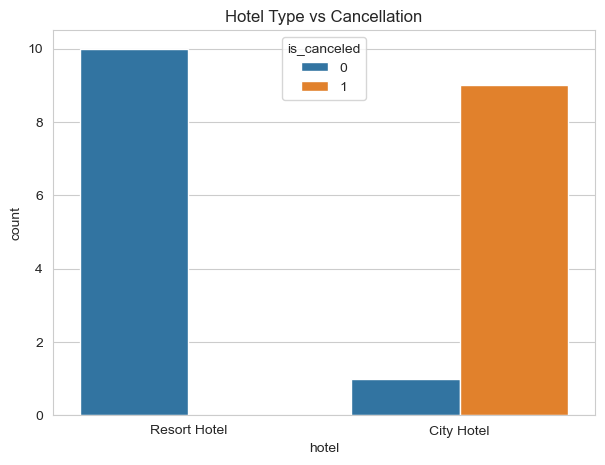

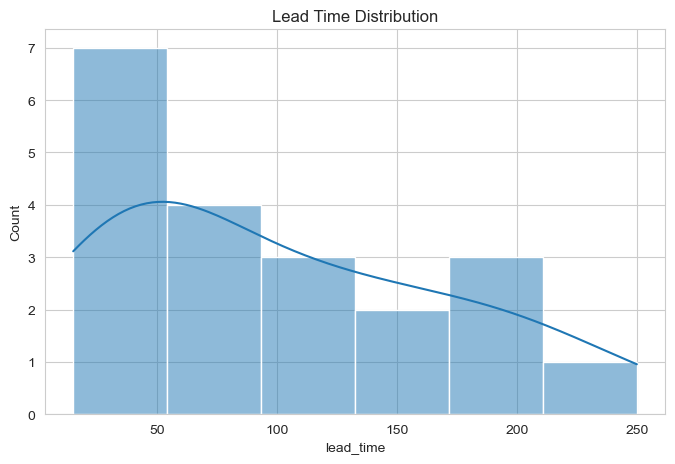

0.6257166052640513


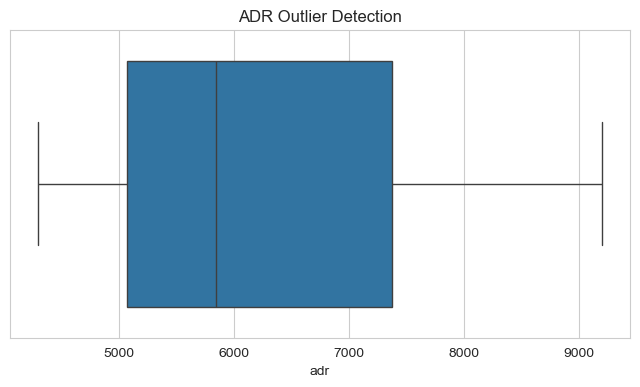

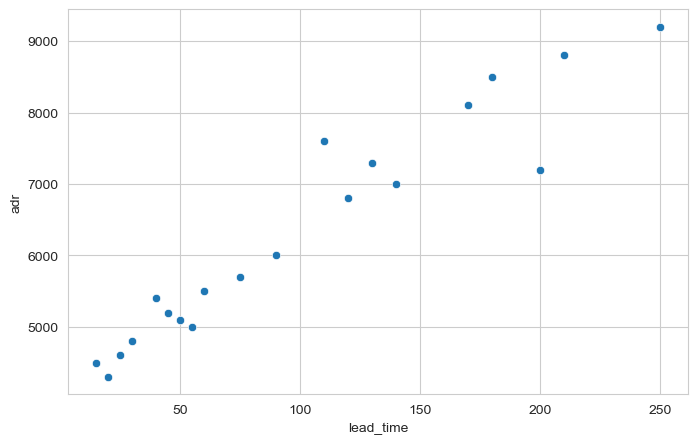

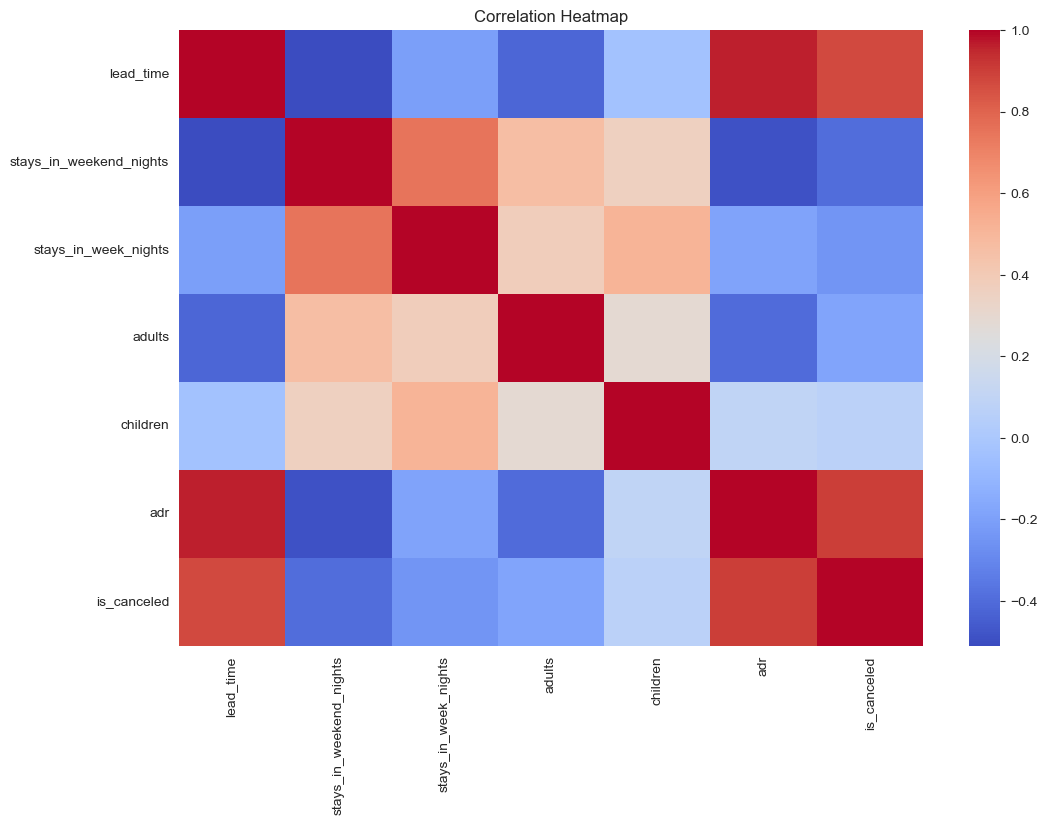

In [5]:
plt.figure(figsize=(6,4)) #Booking Cancellation Distribution
sns.countplot(
    x="is_canceled",
    data=df
)
plt.title("Booking Cancellation Distribution")
plt.show()

plt.figure(figsize=(7,5)) #Hotel Type vs Cancellation
sns.countplot(
    x="hotel",
    hue="is_canceled",
    data=df
)

plt.title("Hotel Type vs Cancellation")
plt.show()


plt.figure(figsize=(8,5)) #Lead Time Distribution
sns.histplot(
    df["lead_time"],
    kde=True
)
plt.title("Lead Time Distribution")
plt.show()

print(df["lead_time"].skew()) #skewness

plt.figure(figsize=(8,4)) #ADR outliers
sns.boxplot(
    x=df["adr"]
)
plt.title("ADR Outlier Detection")
plt.show()


plt.figure(figsize=(8,5)) #Lead Time vs ADR
sns.scatterplot(
    x="lead_time",
    y="adr",
    data=df
)
plt.show()


plt.figure(figsize=(12,8)) #Correlation Heatmap
corr = df.corr(numeric_only=True)
sns.heatmap(
    corr,
    cmap="coolwarm",
    annot=False
)
plt.title("Correlation Heatmap")
plt.show()


df.to_csv(
    "cleaned_dataset.csv",
    index=False
)

# Insights for ML modelling

### 1.Booking Cancellation
 The exploratory analysis revealed that booking cancellations are influenced by multiple factors rather than a single variable. Customers with longer lead times appear more likely to cancel reservations, suggesting that uncertainty increases when bookings are made far in advance.
 ### 2.Feature relationships
 The correlation analysis showed that some numerical features share moderate relationships. While no severe multicollinearity was observed, highly related variables should be monitored during model development to prevent redundant information from affecting model performance.
### 3.Outlier Detection
Several extreme observations were identified within pricing-related attributes. These outliers may disproportionately influence distance-based and regression-based machine learning algorithms. Appropriate techniques such as capping, clipping, logarithmic transformation, or robust scaling should be considered before model training.
### 4.Data quality improvements
To improve dataset reliability, duplicate records were removed and missing values were treated using statistically appropriate imputation techniques. Numerical attributes were validated to ensure correct data types, and the dataset was checked for structural consistency after cleaning.
### 5.Business impacts
Understanding the factors associated with booking cancellations can help hotel management optimize reservation strategies, improve customer retention efforts, and reduce potential revenue losses. The cleaned dataset provides a strong foundation for predictive analytics and cancellation forecasting models.
### 6.Machine learning readness
The final dataset is free from duplicate records, contains no unresolved missing values, and maintains consistent feature formats. These preprocessing steps significantly reduce the risk of model training failures and improve the overall quality of predictive modeling outcomes.



### Conclusion 
    This analysis transformed raw booking information into a structured, machine-learning-ready dataset. The insights obtained during EDA highlight important behavioral patterns, data quality concerns, and business opportunities that can support future predictive modeling and decision-making processes.